In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aarushiagarwalll/myresumedataset/resume_dataset.jsonl


# GPU Availability Check

In [2]:
import torch
torch.cuda.is_available()

True

# Installing Required Libraries

In [3]:
!pip install -q transformers seqeval accelerate

In [4]:
!pip install -U transformers

In [5]:
import pandas as pd
from datasets import Dataset

In [6]:
import torch
import numpy as np
from datasets import Dataset
from transformers import(
    BertTokenizerFast,
    BertForTokenClassification,
    Trainer,
    TrainingArguments
)
from seqeval.metrics import f1_score

# Loading and Inspecting the Resume Dataset

In [7]:
import json

file_path = "/kaggle/input/datasets/aarushiagarwalll/myresumedataset/resume_dataset.jsonl"
data = []

with open(file_path, "r") as f:
    for line in f:
        data.append(json.loads(line))

print(len(data))
print(data[0].keys())

502
dict_keys(['tokens', 'labels', 'file_name'])


# Visualizing Overall NER Label Distribution

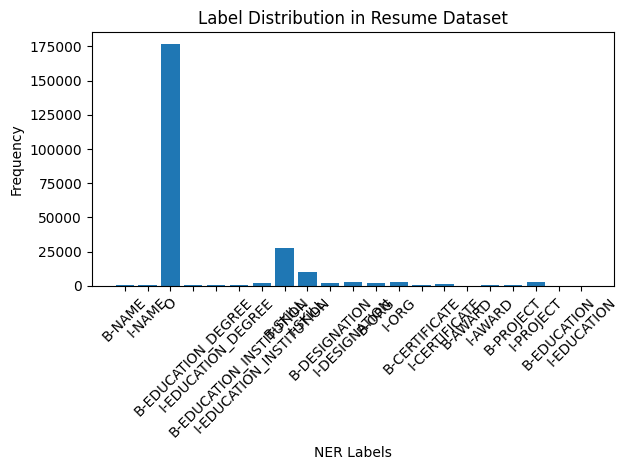

In [8]:
import matplotlib.pyplot as plt
from collections import Counter

label_counter = Counter()

for sample in data:
    for label in sample["labels"]:
        label_counter[label] += 1

labels = list(label_counter.keys())
counts = list(label_counter.values())

plt.figure()
plt.bar(labels, counts)
plt.xlabel("NER Labels")
plt.ylabel("Frequency")
plt.title("Label Distribution in Resume Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Converting Raw Data into a Hugging Face Dataset

In [9]:
from datasets import Dataset
dataset = Dataset.from_list(data)

In [10]:
print(dataset)

Dataset({
    features: ['tokens', 'labels', 'file_name'],
    num_rows: 502
})


# Creating Label Mappings and Counting NER Classes

In [11]:
unique_labels = sorted(set(l for s in dataset for l in s["labels"]))
label2id = {l: i for i, l in enumerate(unique_labels)}
id2label = {i: l for l, i in label2id.items()}
num_labels = len(label2id)
print("Number of labels:", num_labels)

Number of labels: 21


# Initializing the BERT Tokenizer

In [12]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-cased")

# Tokenizing Text and Aligning NER Labels

In [13]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True
    )

    aligned_labels = []

    for i, labels in enumerate(examples["labels"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        prev_word = None
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word:
                label_ids.append(label2id[labels[word_id]])
            else:
                label_ids.append(-100)
            prev_word = word_id

        aligned_labels.append(label_ids)

    tokenized_inputs["labels"] = aligned_labels
    return tokenized_inputs

# Applying Tokenization and Label Alignment to the Dataset

In [14]:
tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset.column_names
)

Map:   0%|          | 0/502 [00:00<?, ? examples/s]

# Splitting the Dataset into Training, Validation, and Test Sets

In [15]:
split1 = tokenized_dataset.train_test_split(test_size=0.15, seed=42)
train_val_dataset = split1["train"]
test_dataset = split1["test"]

split2 = train_val_dataset.train_test_split(test_size=0.1765, seed=42)  
train_dataset = split2["train"]
eval_dataset = split2["test"]

# Computing Label Distributions for Each Dataset Split

In [16]:
from collections import Counter

def get_label_distribution(dataset):
    counter = Counter()
    for sample in dataset:
        for label in sample["labels"]: 
            counter[label] += 1
    return counter

In [17]:
train_dist = get_label_distribution(train_dataset)
val_dist   = get_label_distribution(eval_dataset)
test_dist  = get_label_distribution(test_dataset)

In [18]:
all_labels = sorted(
    set(train_dist.keys()) |
    set(val_dist.keys()) |
    set(test_dist.keys())
)

In [19]:
train_counts = [train_dist.get(l, 0) for l in all_labels]
val_counts   = [val_dist.get(l, 0) for l in all_labels]
test_counts  = [test_dist.get(l, 0) for l in all_labels]

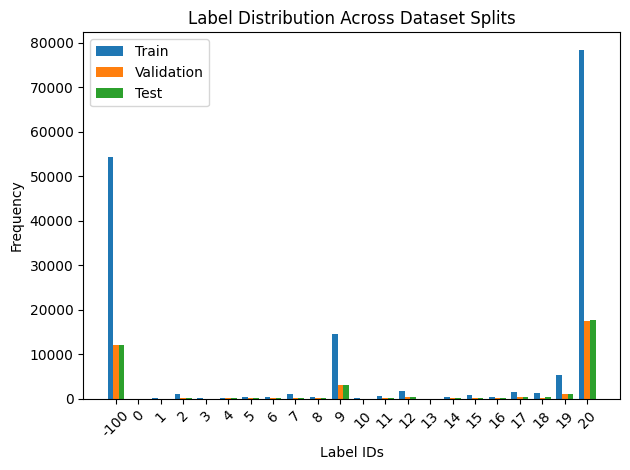

In [20]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(all_labels))
width = 0.25

plt.figure()
plt.bar(x - width, train_counts, width, label="Train")
plt.bar(x,         val_counts,   width, label="Validation")
plt.bar(x + width, test_counts,  width, label="Test")

plt.xlabel("Label IDs")
plt.ylabel("Frequency")
plt.title("Label Distribution Across Dataset Splits")
plt.xticks(x, all_labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Initializing the BERT Model for Token Classification

In [21]:
model = BertForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

# Defining Evaluation Metrics

In [22]:
from seqeval.metrics import f1_score, precision_score, recall_score

def compute_metrics(p):
    preds, labels = p
    preds = np.argmax(preds, axis=2)

    true_preds, true_labels = [], []

    for pred, label in zip(preds, labels):
        p_seq, l_seq = [], []
        for p, l in zip(pred, label):
            if l != -100:
                p_seq.append(id2label[p])
                l_seq.append(id2label[l])
        true_preds.append(p_seq)
        true_labels.append(l_seq)

    return {
        "precision": precision_score(true_labels, true_preds),
        "recall": recall_score(true_labels, true_preds),
        "f1": f1_score(true_labels, true_preds),
    }

# Computing Class Weights to Handle Label Imbalance

In [23]:
from collections import Counter
import torch

label_counter = Counter()

for sample in train_dataset:
    for label_id in sample["labels"]:
        if label_id != -100:
            label_counter[label_id] += 1

class_weights = torch.zeros(num_labels)

for label_id, count in label_counter.items():
    class_weights[label_id] = torch.log(
        torch.tensor(sum(label_counter.values()) / count)
    )

o_label_id = label2id["O"]
class_weights[o_label_id] *= 0.7

class_weights = torch.clamp(class_weights, max=5.0)

print("Final class weights:")
for label, idx in label2id.items():
    print(label, "→", class_weights[idx].item())

Final class weights:
B-AWARD → 5.0
B-CERTIFICATE → 5.0
B-DESIGNATION → 4.579907417297363
B-EDUCATION → 5.0
B-EDUCATION_DEGREE → 5.0
B-EDUCATION_INSTITUTION → 5.0
B-NAME → 5.0
B-ORG → 4.6312947273254395
B-PROJECT → 5.0
B-SKILL → 2.019993305206299
I-AWARD → 5.0
I-CERTIFICATE → 5.0
I-DESIGNATION → 4.093711853027344
I-EDUCATION → 5.0
I-EDUCATION_DEGREE → 5.0
I-EDUCATION_INSTITUTION → 4.801263809204102
I-NAME → 5.0
I-ORG → 4.286650657653809
I-PROJECT → 4.400272846221924
I-SKILL → 3.007274627685547
O → 0.2302108108997345


# Configuring Training Arguments

In [24]:
training_args = TrainingArguments(
    output_dir="./bert-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none"
)

# Importing the Data Collator for Token Classification

In [25]:
from transformers import DataCollatorForTokenClassification

In [26]:
data_collator = DataCollatorForTokenClassification(tokenizer)

# Custom Trainer with Class-Weighted Loss for NER

In [27]:
from torch.nn import CrossEntropyLoss
class WeightedNERTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = CrossEntropyLoss(
            weight=class_weights.to(logits.device),
            ignore_index=-100
        )

        loss = loss_fct(
            logits.view(-1, logits.size(-1)),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

# Initializing the Custom Trainer with Class-Weighted Loss

In [28]:
trainer = WeightedNERTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Training the BERT NER Model with Class-Weighted Loss

In [29]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,2.391199,1.940287,0.203910,0.594733,0.303695
2,1.813265,1.519768,0.254706,0.626183,0.362117
3,1.443840,1.250750,0.269273,0.628739,0.377060
4,1.225968,1.132028,0.348463,0.626183,0.447756
5,1.103700,1.057085,0.345220,0.643569,0.449384
6,1.018277,1.005813,0.342285,0.651751,0.448847
7,0.947496,0.968125,0.316409,0.673996,0.430649
8,0.889907,0.951682,0.327318,0.700332,0.446128
9,0.858745,0.932333,0.320217,0.680389,0.435480
10,0.833284,0.920608,0.329163,0.699565,0.447681


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=110, training_loss=1.252568123557351, metrics={'train_runtime': 245.1107, 'train_samples_per_second': 14.279, 'train_steps_per_second': 0.449, 'total_flos': 914695746048000.0, 'train_loss': 1.252568123557351, 'epoch': 10.0})

# Evaluating Model Performance on Validation and Test Sets

In [30]:
print("\nVALIDATION METRICS")
val_metrics = trainer.evaluate(eval_dataset)
print(val_metrics)

print("\nTEST METRICS")
test_metrics = trainer.evaluate(test_dataset)
print(test_metrics)

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



VALIDATION METRICS


{'eval_loss': 0.9206078052520752, 'eval_precision': 0.329162656400385, 'eval_recall': 0.6995653285604705, 'eval_f1': 0.4476806021435, 'eval_runtime': 1.7348, 'eval_samples_per_second': 43.81, 'eval_steps_per_second': 1.729, 'epoch': 10.0}

TEST METRICS
{'eval_loss': 0.9050624966621399, 'eval_precision': 0.33980821244160314, 'eval_recall': 0.7061829330608074, 'eval_f1': 0.45883134130146086, 'eval_runtime': 1.6903, 'eval_samples_per_second': 44.963, 'eval_steps_per_second': 1.775, 'epoch': 10.0}


# Creating Confusion Matrix

In [31]:
from torch.utils.data import DataLoader

val_dataloader = DataLoader(
    eval_dataset,   
    batch_size=16, 
    shuffle=False  
)

In [32]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer)

val_dataloader = DataLoader(
    eval_dataset,
    batch_size=16,
    collate_fn=data_collator,  
)

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

In [34]:
all_labels = []
all_preds = []

model.eval()

for batch in val_dataloader:
    batch = {k:v.to(device) for k,v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
    
    logits = outputs.logits
    preds = torch.argmax(logits, dim=-1)

    labels = batch["labels"]

    mask = labels != -100
    all_labels.extend(labels[mask].cpu().numpy())
    all_preds.extend(preds[mask].cpu().numpy())

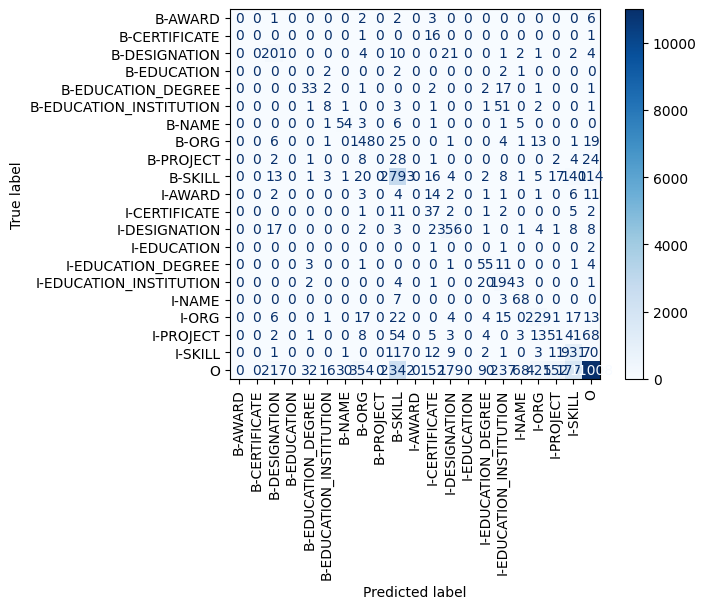

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=list(label2id.keys()))
disp.plot(xticks_rotation='vertical', cmap='Blues')
plt.show()

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [37]:
model.eval()

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

# Prediction

In [38]:
def predict_ner(sentence, tokenizer, model, id2label, device):
    tokens = sentence.split()

    encoding = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True
    )

    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding)

    predictions = torch.argmax(outputs.logits, dim=-1)[0].tolist()
    word_ids = encoding["input_ids"].cpu()
    word_ids = tokenizer(
        tokens,
        is_split_into_words=True
    ).word_ids()

    results = []
    previous_word_idx = None

    for token, word_idx, pred_id in zip(
        tokenizer(tokens, is_split_into_words=True).tokens(),
        word_ids,
        predictions
    ):
        if word_idx is None or word_idx == previous_word_idx:
            continue
        results.append((tokens[word_idx], id2label[pred_id]))
        previous_word_idx = word_idx

    return results

In [39]:
sentence = "milan singh bengaluru india + summary senior data scientist 7.5+ years experience driving innovation generative agentic ai nlp rag autonomous workflow solutions. expert building autonomous agents rag pipelines nlp-driven systems using llms cloud infrastructure. passionate transforming unstructured data actionable intelligence building scalable ai systems enhance business efficiency. skills programming languages python pyspark sql genai amp agentic ai langgraph crewai openai rag langchain vector db prompt engineering ml amp deep learning random forest xgboost recommendation systems neural networks keras pytorch vector db amp infra pinecone chromadb faiss docker github ci cd pipelines cloud amp tools aws azure streamlit flask django visualization powerbi tableau work experience apexon senior data scientist may 2024 - present bengaluru india - led development text-to-sql chatbot enabling non-technical stakeholders query databases via natural language reducing analyst dependencies 40%. - built agentic ai hiring assistant automating candidate sourcing screening l2 interview preparation using langgraph reduced recruiter manual effort 60% shortened hiring cycles 35%. - deployed rag-powered document-level qa assistant pinecone achieving 92% accuracy across 10k+ pdfs - amp helped sales team access contract amp feature info 80% faster boosting deal conversions 12% 3 months - deployed xgboost-based customer call prediction model real-time classification support dashboards reducing average call handling time 40% improving first-call resolution rate 22%. - rag pinecone vector db openai aws bedrock models python prompt engineering langchain embeddings xgboost postgresql aws athena django streamlit github ormae llp senior data scientist bengaluru india apr 2022 - apr 2024 - built azure-based gpt-3 openai pipeline auto-summarize seller feedback reduced manual review time 65% across 3 teams. - developed b2b recommendation system using user-item matrix behavior vectors increased cross-sell rate 18% pilot deployments. - deployed employee attrition risk model azure streamlit ui using ci cd pipelines identified at-risk profiles 78% recall. - built bert-based phrase-matching model cluster seller comments improving feedback categorization speeding insight generation business teams 3x. - bert python azure openai models huggingface text summarization embeddings nlp prompt engineering collaborative filtering recommendation systems streamlit ci cd pipelines nltk scikit-learn zenon analytics pvt ltd. data scientist mar 2020 - mar 2022 new delhi india - implemented bert model highly imbalanced dataset classify news articles 20 distinct categories achieved 94% model accuracy. - developed streamlit-based customer journey dashboard sankey visualization dynamic kpis monitor user flow detect anomalies cutting manual reporting time 50%. - automated generation bivariant charts reporting improved weekly analytics efficiency stakeholders. - consolidated 400m+ records unstructured public sources clean master dataset downstream tasks. - bert python huggingface embeddings nltk pyspark sql etl databricks ms excel draup.com data scientist bengaluru india july 2018 - feb 2020 - developed named entity recognition ner system using crf extract query parameters user input achieved 80% f1 score . - trained word2vec model 30m job descriptions expand skill recognition database enterprise recruiting. - built gender classification model using random forest 90% accuracy based name features. - ner python nlp word2vec random forest embeddings regex databricks scikit-learn gensim nltk aquafil s.p.a. product development intern may 2017 - july 2017 arco italy - optimized textile flooring production process analyzing bcf applications reducing raw material energy consumption 17% saving 45 labor hours per day increasing profitability 1 000 daily. education indian institute technology iit delhi new delhi india b.tech textile technology jun 2014 - jun 2018 awards amp certificates - first runner - apexon agentic ai prompthon 2025 selected 500+ participants excellence autonomous agent design - awarded certificate appreciation quality deliverable per client expectation apexon amp ormae - agentic ai empowerment fundamentals autonomous agents - udemy - generative ai llms nlp specialization - deeplearning.ai coursera"
print(predict_ner(sentence, tokenizer, model, id2label, device))

Token indices sequence length is longer than the specified maximum sequence length for this model (1016 > 512). Running this sequence through the model will result in indexing errors


[('milan', 'B-NAME'), ('singh', 'I-NAME'), ('bengaluru', 'I-NAME'), ('india', 'I-ORG'), ('+', 'O'), ('summary', 'O'), ('senior', 'B-DESIGNATION'), ('data', 'I-DESIGNATION'), ('scientist', 'I-DESIGNATION'), ('7.5+', 'O'), ('years', 'O'), ('experience', 'O'), ('driving', 'O'), ('innovation', 'O'), ('generative', 'B-SKILL'), ('agentic', 'B-SKILL'), ('ai', 'B-SKILL'), ('nlp', 'B-SKILL'), ('rag', 'B-SKILL'), ('autonomous', 'B-SKILL'), ('workflow', 'I-SKILL'), ('solutions.', 'I-SKILL'), ('expert', 'O'), ('building', 'I-SKILL'), ('autonomous', 'B-SKILL'), ('agents', 'I-SKILL'), ('rag', 'B-SKILL'), ('pipelines', 'I-SKILL'), ('nlp-driven', 'B-SKILL'), ('systems', 'I-SKILL'), ('using', 'O'), ('llms', 'B-SKILL'), ('cloud', 'I-SKILL'), ('infrastructure.', 'I-SKILL'), ('passionate', 'O'), ('transforming', 'O'), ('unstructured', 'O'), ('data', 'O'), ('actionable', 'O'), ('intelligence', 'B-SKILL'), ('building', 'I-SKILL'), ('scalable', 'O'), ('ai', 'B-SKILL'), ('systems', 'I-SKILL'), ('enhance', 'O'

In [40]:
sentence = " Swami Keshvanand is data scientist.She studied at swami keshvanand school.She has worked on projects like swami keshvanand project"
print(predict_ner(sentence, tokenizer, model, id2label, device))

[('Swami', 'B-NAME'), ('Keshvanand', 'I-NAME'), ('is', 'I-ORG'), ('data', 'B-DESIGNATION'), ('scientist.She', 'I-DESIGNATION'), ('studied', 'I-EDUCATION_INSTITUTION'), ('at', 'I-EDUCATION_INSTITUTION'), ('swami', 'I-EDUCATION_INSTITUTION'), ('keshvanand', 'I-NAME'), ('school.She', 'I-EDUCATION_INSTITUTION'), ('has', 'O'), ('worked', 'O'), ('on', 'O'), ('projects', 'O'), ('like', 'O'), ('swami', 'I-NAME'), ('keshvanand', 'I-NAME'), ('project', 'I-ORG')]


In [41]:
sentence = "nishant singh lead data scientist gurgaon india + profile seasoned data scientist 7+ years experience designing deploying advanced computer vision nlp solutions strong focus large-scale resume parsing analysis. highly skilled utilizing cloud platforms aws sagemaker gcp vertex scalable machine learning model development deployment. proven ability lead technical teams drive impactful ai projects global clients deliver operational efficiencies automation innovative analytics certifications - keras certification custom callbacks - cutshort machine learning certificate - cutshort python certificate - accelerated computing cuda python technical skills - programming languages python sql go - data science eda time series forecasting regression classification clustering ensemble modeling dimensionality reduction anomaly detection optimization techniques - generative ai llms prompt engineering langchain langgraph langfuse rag agents google adk vectordb prompt engineering lora qlora llamaindex - natural language processing ner pii redaction sentiment analysis keyword extraction text generation embedding representation transformers bert word2vec glove tf-idf bow - computer vision ocr object detection image segmentation unet canet object tracking deepsort face verification siamese networks gan-based anomaly detection - libraries amp frameworks pytorch keras tensorrt nvidia numba flask tensorflow - ml ops amp deployment end-to-end ml pipelines cloud-native architecture docker git rag pipelines fastapi - could services aws sagemaker ground truth s3 ecs gcp vertex ai pipelines bigquery prefect mlflow azure ai foundry cloud9 experience vmock gurgaon lead data scientist - led resume parser jd parser optimizer cover letter linkedin aspire products mentoring junior data scientists across multiple projects impacting 250+ clients globally - architected modular section-aware genai resume parser splits resumes sections routes specialized extractors parallelized execution streaming reduce end-to-end latency timeouts boosting entity-level accuracy 15% . - built centralized genai service resume parsing grammar correction interview feedback using langchain daily traffic around 100k+ - delivered multilingual genai backend supporting 5+ languages like english spanish french german etc. across resume jd parsing optimization cover letters linkedin features via generalized llm pipeline auto language detection per-locale prompt packs taxonomies high-accuracy locale-aware outputs. - developed tailored solutions 250+ universities staffing organizations including resume cover letter generation genai capabilities - engineered in-house pii redaction system sanitize sensitive data ensure client privacy 97.5+% accuracy across entities names address phone number etc. - created ai agent framework applying google adk simulate career coach chatbot guiding candidates increase user engagement - orchestrated genai services aws ecs distinct sync api async worker fleets behind alb using sqs job queues s3 payload staging implemented auto-scaling via target tracking cpu memory step scaling custom cloudwatch metrics scheduled scaling predictable peaks. august 2024 - present shadowfax bangalore associate lead data scientist - developed ocr pipeline achieving approximately 98% accuracy extracting entities government records - created face verification system employing siamese networks enhance fraud detection leading 60% reduction fake logins app - implemented automated entity recognition engine address customer address patterns streamline pincode updates 18 000 pincodes - designed geocoding engine based 50m+ customer address data using embedding representation vectordb covers 70% addresses across pan india 85% metro cities - launched on-spot run sheet creation order auto allocation geocoding engine top metro cities leading reduction rider-hub wait time 30% increased order assignment 75% 78% - established pipelines custom training jobs gcp vertex ai platform daily-level analyses fraud cases - built workflow orchestration using prefect optimizing data transformation flows managing docker images - guided team business use cases including rain classification entity extraction color detection collaboration data science team qunatiphi bangalore machine learning engineer april 2021 - july 2022 - built deployed advanced computer vision systems including object detection image segmentation action recognition real-time safety - delivered 98.5% precision 99% recall allowing automated detection 80% visitor safety issues drove major increase site compliance risk reduction - implemented object tracking deepsort anomaly detection operating gans pytorch aws sagemaker. optimized inference pipeline utilizing tensorrt leading 45% latency reduction minimal reduction model performance - dockerised data preprocessing model training monitoring hyperparameter tuning pipelines aws sagemaker streamline entire development process - monitored training jobs aws cloudwatch ensure operational efficiency pipeline handling 50k+ visitors daily basis - created labeling jobs object detection tracking polygons points via aws ground truth 2m+ frames subsampling self employed kolkata analyst data science february 2019 - february 2021 - conducted data analysis jeweler association kolkata generating sales forecasts across various 50+ skus leveraging time series analysis - acquired proficiency classification regression clustering algorithms implementation diverse machine learning deep learning projects - developed image segmentation solutions utilizing unet canet fpn architectures rc car systems 0.95 iou - engineered obstacle detection system ride paths rc cars enhance navigation capabilities accenture bangalore india associate software engineer - trained multiple machine learning deep learning methodologies - applied diverse pre-processing techniques followed machine learning models banking-related customer queries data - acquired insights deploying models using flask framework - worked industry-standard models including attention bert nlp lstm education b.e. february 2018 - january 2019"
print(predict_ner(sentence, tokenizer, model, id2label, device))

[('nishant', 'B-NAME'), ('singh', 'I-NAME'), ('lead', 'B-DESIGNATION'), ('data', 'I-DESIGNATION'), ('scientist', 'I-DESIGNATION'), ('gurgaon', 'I-EDUCATION_INSTITUTION'), ('india', 'I-ORG'), ('+', 'B-DESIGNATION'), ('profile', 'O'), ('seasoned', 'B-DESIGNATION'), ('data', 'B-DESIGNATION'), ('scientist', 'I-DESIGNATION'), ('7+', 'O'), ('years', 'O'), ('experience', 'O'), ('designing', 'O'), ('deploying', 'O'), ('advanced', 'O'), ('computer', 'B-SKILL'), ('vision', 'I-SKILL'), ('nlp', 'B-SKILL'), ('solutions', 'O'), ('strong', 'O'), ('focus', 'O'), ('large-scale', 'O'), ('resume', 'B-SKILL'), ('parsing', 'I-SKILL'), ('analysis.', 'I-SKILL'), ('highly', 'O'), ('skilled', 'O'), ('utilizing', 'O'), ('cloud', 'B-SKILL'), ('platforms', 'I-SKILL'), ('aws', 'B-SKILL'), ('sagemaker', 'B-SKILL'), ('gcp', 'B-SKILL'), ('vertex', 'B-SKILL'), ('scalable', 'I-SKILL'), ('machine', 'B-SKILL'), ('learning', 'I-SKILL'), ('model', 'B-SKILL'), ('development', 'I-SKILL'), ('deployment.', 'O'), ('proven', 'O'

In [42]:
sentence = "krishnkant sharma python django developer mobile email experience years month professional summary years month experience backend technology like core python django drf fastapi python scripts"
print(predict_ner(sentence, tokenizer, model, id2label, device))

[('krishnkant', 'B-NAME'), ('sharma', 'I-NAME'), ('python', 'B-SKILL'), ('django', 'B-DESIGNATION'), ('developer', 'I-DESIGNATION'), ('mobile', 'O'), ('email', 'O'), ('experience', 'O'), ('years', 'O'), ('month', 'O'), ('professional', 'O'), ('summary', 'O'), ('years', 'O'), ('month', 'O'), ('experience', 'O'), ('backend', 'O'), ('technology', 'O'), ('like', 'O'), ('core', 'I-PROJECT'), ('python', 'B-SKILL'), ('django', 'B-SKILL'), ('drf', 'B-SKILL'), ('fastapi', 'B-SKILL'), ('python', 'B-SKILL'), ('scripts', 'I-ORG')]


In [43]:
def func(tokens):
    sentence = " ".join([str(token) for token in tokens])
    print(sentence)

In [44]:
tokens = ["manas", "gupta", "software", "engineer", "data", "engineering", "engineer", "years", "hands", "experience", "designing", "implementing", "optimizing", "scalable", "data", "solutions", "proficient", "big", "data", "technologies", "etl", "processes", "data", "pipelines", "quality", "assurance", "linkedin", "com", "manasgupta", "skills", "python", "airflow", "mysql", "aws", "emr", "aws", "sns", "fastapi", "trino", "pyspark", "aws", "glue", "aws", "iceberg", "dbt", "kafka", "aws", "kinesis", "aws", "ec", "aws", "athena", "bit", "bucket", "aws", "lambda", "aws", "dynamodb", "aws", "event", "bridge", "spark", "streaming", "aws", "opensearch", "interests", "stock", "market", "trading", "competitive", "coding", "ai", "enthusiast", "cricket", "travelling", "work", "experience", "sde", "senior", "data", "engineer", "baazi", "games", "pokerbaazi", "present", "developed", "lakehouse", "using", "cdc", "pipeline", "leveraging", "kafka", "aws", "glue", "catalog", "iceberg", "tables", "orchestrated", "apache", "airflow", "near", "real", "time", "updates", "developed", "personalized", "year", "end", "insights", "pokerbaazi", "player", "displayed", "slides", "app", "front", "page", "optimized", "data", "processing", "using", "aws", "emr", "spark", "python", "dynamodb", "multi", "threading", "asynchronous", "programming", "built", "real", "time", "data", "pipeline", "using", "spark", "streaming", "aws", "kinesis", "aws", "glue", "process", "player", "stats", "opensearch", "data", "automation", "crm", "marketing", "platform", "server", "server", "api", "integration", "smooth", "transmission", "data", "internal", "warehouse", "crm", "platform", "vice", "versa", "reduces", "manual", "effort", "marketing", "team", "streamlined", "dbt", "query", "pipelines", "automated", "cascading", "data", "processes", "aws", "airflow", "mwaa", "minimising", "pipeline", "setup", "time", "improving", "reliability", "developed", "high", "performance", "rest", "api", "using", "python", "mysql", "fastapi", "reduced", "response", "time", "via", "api", "restructuring", "using", "benefits", "asynchronous", "programming", "decoupling", "sde", "data", "engineer", "new", "migrated", "data", "mysql", "using", "aws", "emr", "airflow", "pyspark", "also", "handled", "upsert", "operations", "gracefully", "real", "time", "invoice", "generation", "system", "aws", "lambda", "aws", "sqs", "reportlab", "automate", "invoice", "creation", "delivery", "reducing", "manual", "effort", "built", "sanity", "jobs", "using", "python", "pyspark", "deequ", "perform", "data", "quality", "checks", "ensuring", "data", "integrity", "consistency", "across", "pipelines", "education", "tech", "computer", "science", "engineering", "ims", "engineering", "college", "ghaziabad", "senior", "secondary", "isc", "st", "mary", "school", "bijnor", "achievements", "got", "national", "rank", "graduation", "batch", "rank", "codekaze", "india", "coding", "competition", "conducted", "coding", "ninjas", "march", "databricks", "certified", "associate", "developer", "apache", "spark", "solved", "problems", "leetcode"]
func(tokens)

manas gupta software engineer data engineering engineer years hands experience designing implementing optimizing scalable data solutions proficient big data technologies etl processes data pipelines quality assurance linkedin com manasgupta skills python airflow mysql aws emr aws sns fastapi trino pyspark aws glue aws iceberg dbt kafka aws kinesis aws ec aws athena bit bucket aws lambda aws dynamodb aws event bridge spark streaming aws opensearch interests stock market trading competitive coding ai enthusiast cricket travelling work experience sde senior data engineer baazi games pokerbaazi present developed lakehouse using cdc pipeline leveraging kafka aws glue catalog iceberg tables orchestrated apache airflow near real time updates developed personalized year end insights pokerbaazi player displayed slides app front page optimized data processing using aws emr spark python dynamodb multi threading asynchronous programming built real time data pipeline using spark streaming aws kines

In [45]:
sentence = "manas gupta software engineer data engineering engineer years hands experience designing implementing optimizing scalable data solutions proficient big data technologies etl processes data pipelines quality assurance linkedin com manasgupta skills python airflow mysql aws emr aws sns fastapi trino pyspark aws glue aws iceberg dbt kafka aws kinesis aws ec aws athena bit bucket aws lambda aws dynamodb aws event bridge spark streaming aws opensearch interests stock market trading competitive coding ai enthusiast cricket travelling work experience sde senior data engineer baazi games pokerbaazi present developed lakehouse using cdc pipeline leveraging kafka aws glue catalog iceberg tables orchestrated apache airflow near real time updates developed personalized year end insights pokerbaazi player displayed slides app front page optimized data processing using aws emr spark python dynamodb multi threading asynchronous programming built real time data pipeline using spark streaming aws kinesis aws glue process player stats opensearch data automation crm marketing platform server server api integration smooth transmission data internal warehouse crm platform vice versa reduces manual effort marketing team streamlined dbt query pipelines automated cascading data processes aws airflow mwaa minimising pipeline setup time improving reliability developed high performance rest api using python mysql fastapi reduced response time via api restructuring using benefits asynchronous programming decoupling sde data engineer new migrated data mysql using aws emr airflow pyspark also handled upsert operations gracefully real time invoice generation system aws lambda aws sqs reportlab automate invoice creation delivery reducing manual effort built sanity jobs using python pyspark deequ perform data quality checks ensuring data integrity consistency across pipelines education tech computer science engineering ims engineering college ghaziabad senior secondary isc st mary school bijnor achievements got national rank graduation batch rank codekaze india coding competition conducted coding ninjas march databricks certified associate developer apache spark solved problems leetcode"
print(predict_ner(sentence, tokenizer, model, id2label, device))

[('manas', 'B-NAME'), ('gupta', 'I-NAME'), ('software', 'B-DESIGNATION'), ('engineer', 'I-DESIGNATION'), ('data', 'B-DESIGNATION'), ('engineering', 'I-DESIGNATION'), ('engineer', 'I-DESIGNATION'), ('years', 'O'), ('hands', 'O'), ('experience', 'O'), ('designing', 'O'), ('implementing', 'O'), ('optimizing', 'O'), ('scalable', 'O'), ('data', 'O'), ('solutions', 'O'), ('proficient', 'O'), ('big', 'O'), ('data', 'I-SKILL'), ('technologies', 'I-SKILL'), ('etl', 'B-SKILL'), ('processes', 'I-SKILL'), ('data', 'B-SKILL'), ('pipelines', 'I-SKILL'), ('quality', 'B-SKILL'), ('assurance', 'I-SKILL'), ('linkedin', 'B-SKILL'), ('com', 'O'), ('manasgupta', 'B-SKILL'), ('skills', 'O'), ('python', 'B-SKILL'), ('airflow', 'B-SKILL'), ('mysql', 'B-SKILL'), ('aws', 'B-SKILL'), ('emr', 'I-SKILL'), ('aws', 'B-SKILL'), ('sns', 'B-SKILL'), ('fastapi', 'B-SKILL'), ('trino', 'B-SKILL'), ('pyspark', 'B-SKILL'), ('aws', 'B-SKILL'), ('glue', 'I-SKILL'), ('aws', 'B-SKILL'), ('iceberg', 'B-SKILL'), ('dbt', 'B-SKILL'